# Hawaii SCHISM Tutorial

This notebook demonstrates how to run the SCHISM ocean model for the
Hawaii coast using the `coastal_calibration` Python API.

The workflow mirrors the SFINCS pipeline: given a **prebuilt model
directory** and a **geogrid file** the runner downloads forcing data,
regrids atmospheric forcing, generates boundary conditions, runs
SCHISM, and produces comparison plots against NOAA CO-OPS tide gauge
observations.

## Prerequisites

- The **pixi `schism` environment** must be active so that `pschism`,
  `metis_prep`, `gpmetis`, and other SCHISM binaries are on `$PATH`.
- **Pre-built model files** (hgrid.gr3, vgrid.in, param.nml,
  bctides.in, nwmReaches.csv, etc.).
- A **geogrid file** (e.g. `geo_em_HI.nc`) for atmospheric forcing
  regridding.

## Setup

In [1]:
from __future__ import annotations

import os
from pathlib import Path

notebook_dir = Path.cwd()  # assumes notebook is run from docs/examples/notebooks/
os.chdir(notebook_dir.parent / "hawaii")

## 1. Build the run configuration

`CoastalCalibConfig.from_dict` accepts the same dictionary structure as
the run YAML file.  The interface is identical to the SFINCS workflow:
`prebuilt_dir` and `geogrid_file` under `model_config` point to the
model inputs, `work_dir` is the run directory, and `raw_download_dir`
is where NWM data is cached.

In [2]:
from coastal_calibration import CoastalCalibConfig, CoastalCalibRunner, configure_logger

configure_logger(level="INFO")

run_config = CoastalCalibConfig.from_dict(
    {
        "model": "schism",
        "simulation": {
            "start_date": "2024-01-09",
            "duration_hours": 3,
            "coastal_domain": "hawaii",
            "meteo_source": "nwm_ana",
            "timestep_seconds": 200,
        },
        "boundary": {"source": "stofs"},
        "paths": {
            "work_dir": "./run",
            "raw_download_dir": "../downloads",
        },
        "download": {"enabled": True},
        "model_config": {
            "prebuilt_dir": "/Volumes/data/schism_models/hawaii",
            "geogrid_file": "/Volumes/data/schism_models/geo_em_HI.nc",
            "nodes": 1,
            "ntasks_per_node": 4,
            "nscribes": 2,
            "oversubscribe": True,
            "include_noaa_gages": True,
        },
    }
)

print(f"Work directory: {run_config.paths.work_dir}")
print(f"Prebuilt dir:   {run_config.model_config.prebuilt_dir}")
print(f"Domain:         {run_config.simulation.coastal_domain}")
print(f"Duration:       {run_config.simulation.duration_hours}h")

Work directory: /Users/tchegini/repos/nwm-coastal-dev/docs/examples/hawaii/run
Prebuilt dir:   /Volumes/data/schism_models/hawaii
Domain:         hawaii
Duration:       3h


## 2. Run the pipeline

`CoastalCalibRunner` executes all stages in order:

1. `download` — fetch NWM CHRTOUT, LDASIN, and STOFS data
2. `schism_forcing_prep` — stage LDASIN files
3. `schism_forcing` — ESMF regridding of atmospheric forcing (MPI)
4. `schism_sflux` — generate sflux files
5. `schism_params` — create param.nml, symlink mesh files
6. `schism_obs` — discover NOAA tide gauge stations
7. `schism_boundary` — boundary forcing (TPXO or STOFS → elev2D.th.nc)
8. `schism_prep` — discharge generation, mesh partitioning
9. `schism_run` — run `pschism` via `mpiexec`
10. `schism_postprocess` — check outputs, combine hotstarts
11. `schism_plot` — sim vs obs comparison plots

In [3]:
runner = CoastalCalibRunner(run_config)
result = runner.run()
if not result.success:
    raise RuntimeError(f"Pipeline failed at stage '{result.stages_failed}': {result.errors}")
print(result)

Coastal Calibration Workflow                                                    
Start Time: 2026-03-23 14:34:14                                                 
----------------------------------------                                        
Stage: download                                                                 
Start Time: 2026-03-23 14:34:14                                                 
  Download input data (NWM, STOFS)                                              
  meteo/nwm_ana: 4/4 [OK]                                                       
  hydro/nwm: 16/16 [OK]                                                         
  coastal/stofs: 1/1 [OK]                                                       
  Total: 21/21 (failed: 0)                                                      
  Download complete — raw files stored in                                       
/Users/tchegini/repos/nwm-coastal-dev/docs/examples/downloads                   
  [✓] COMPLETED (1s)        

WorkflowResult: SUCCESS
  Start:     2026-03-23 14:34:14
  End:       2026-03-23 14:45:39
  Duration:  11m 24s
  Completed: download, schism_forcing_prep, schism_forcing, schism_sflux, schism_params, schism_obs, schism_boundary, schism_prep, schism_run, schism_postprocess, schism_plot


## 3. View results

The pipeline generates station comparison plots (modeled vs. observed
water levels at NOAA CO-OPS tide gauges).

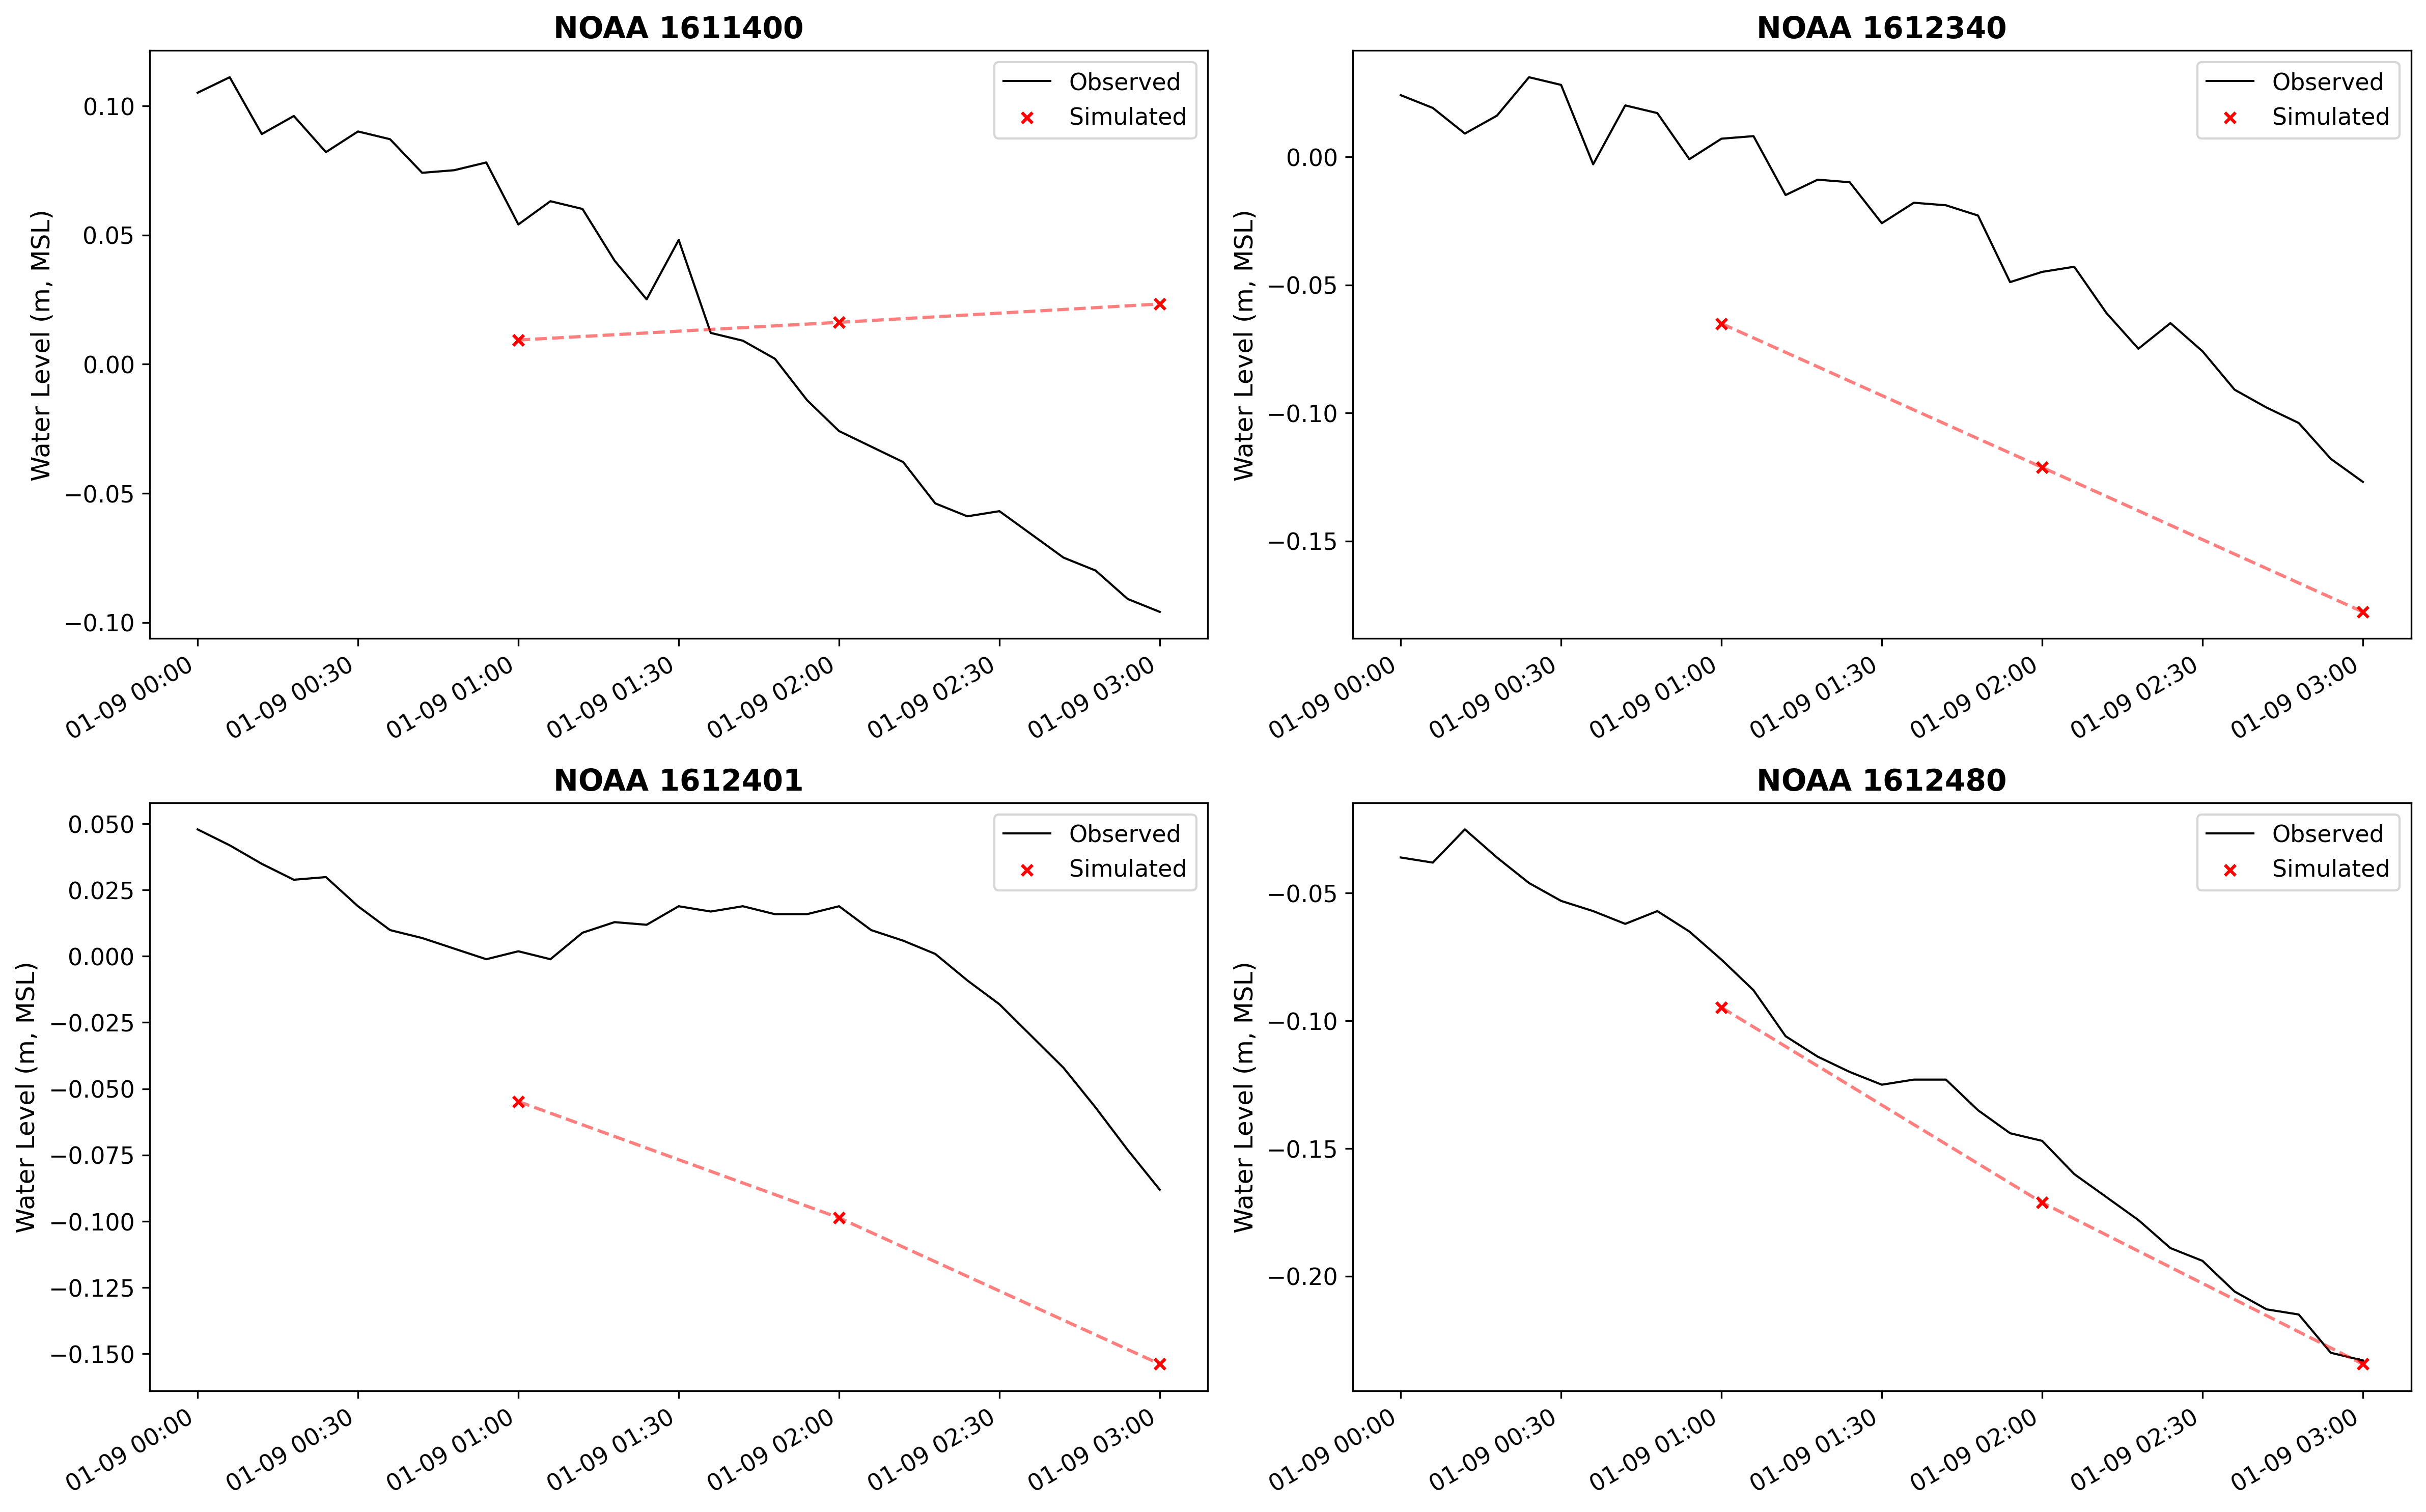

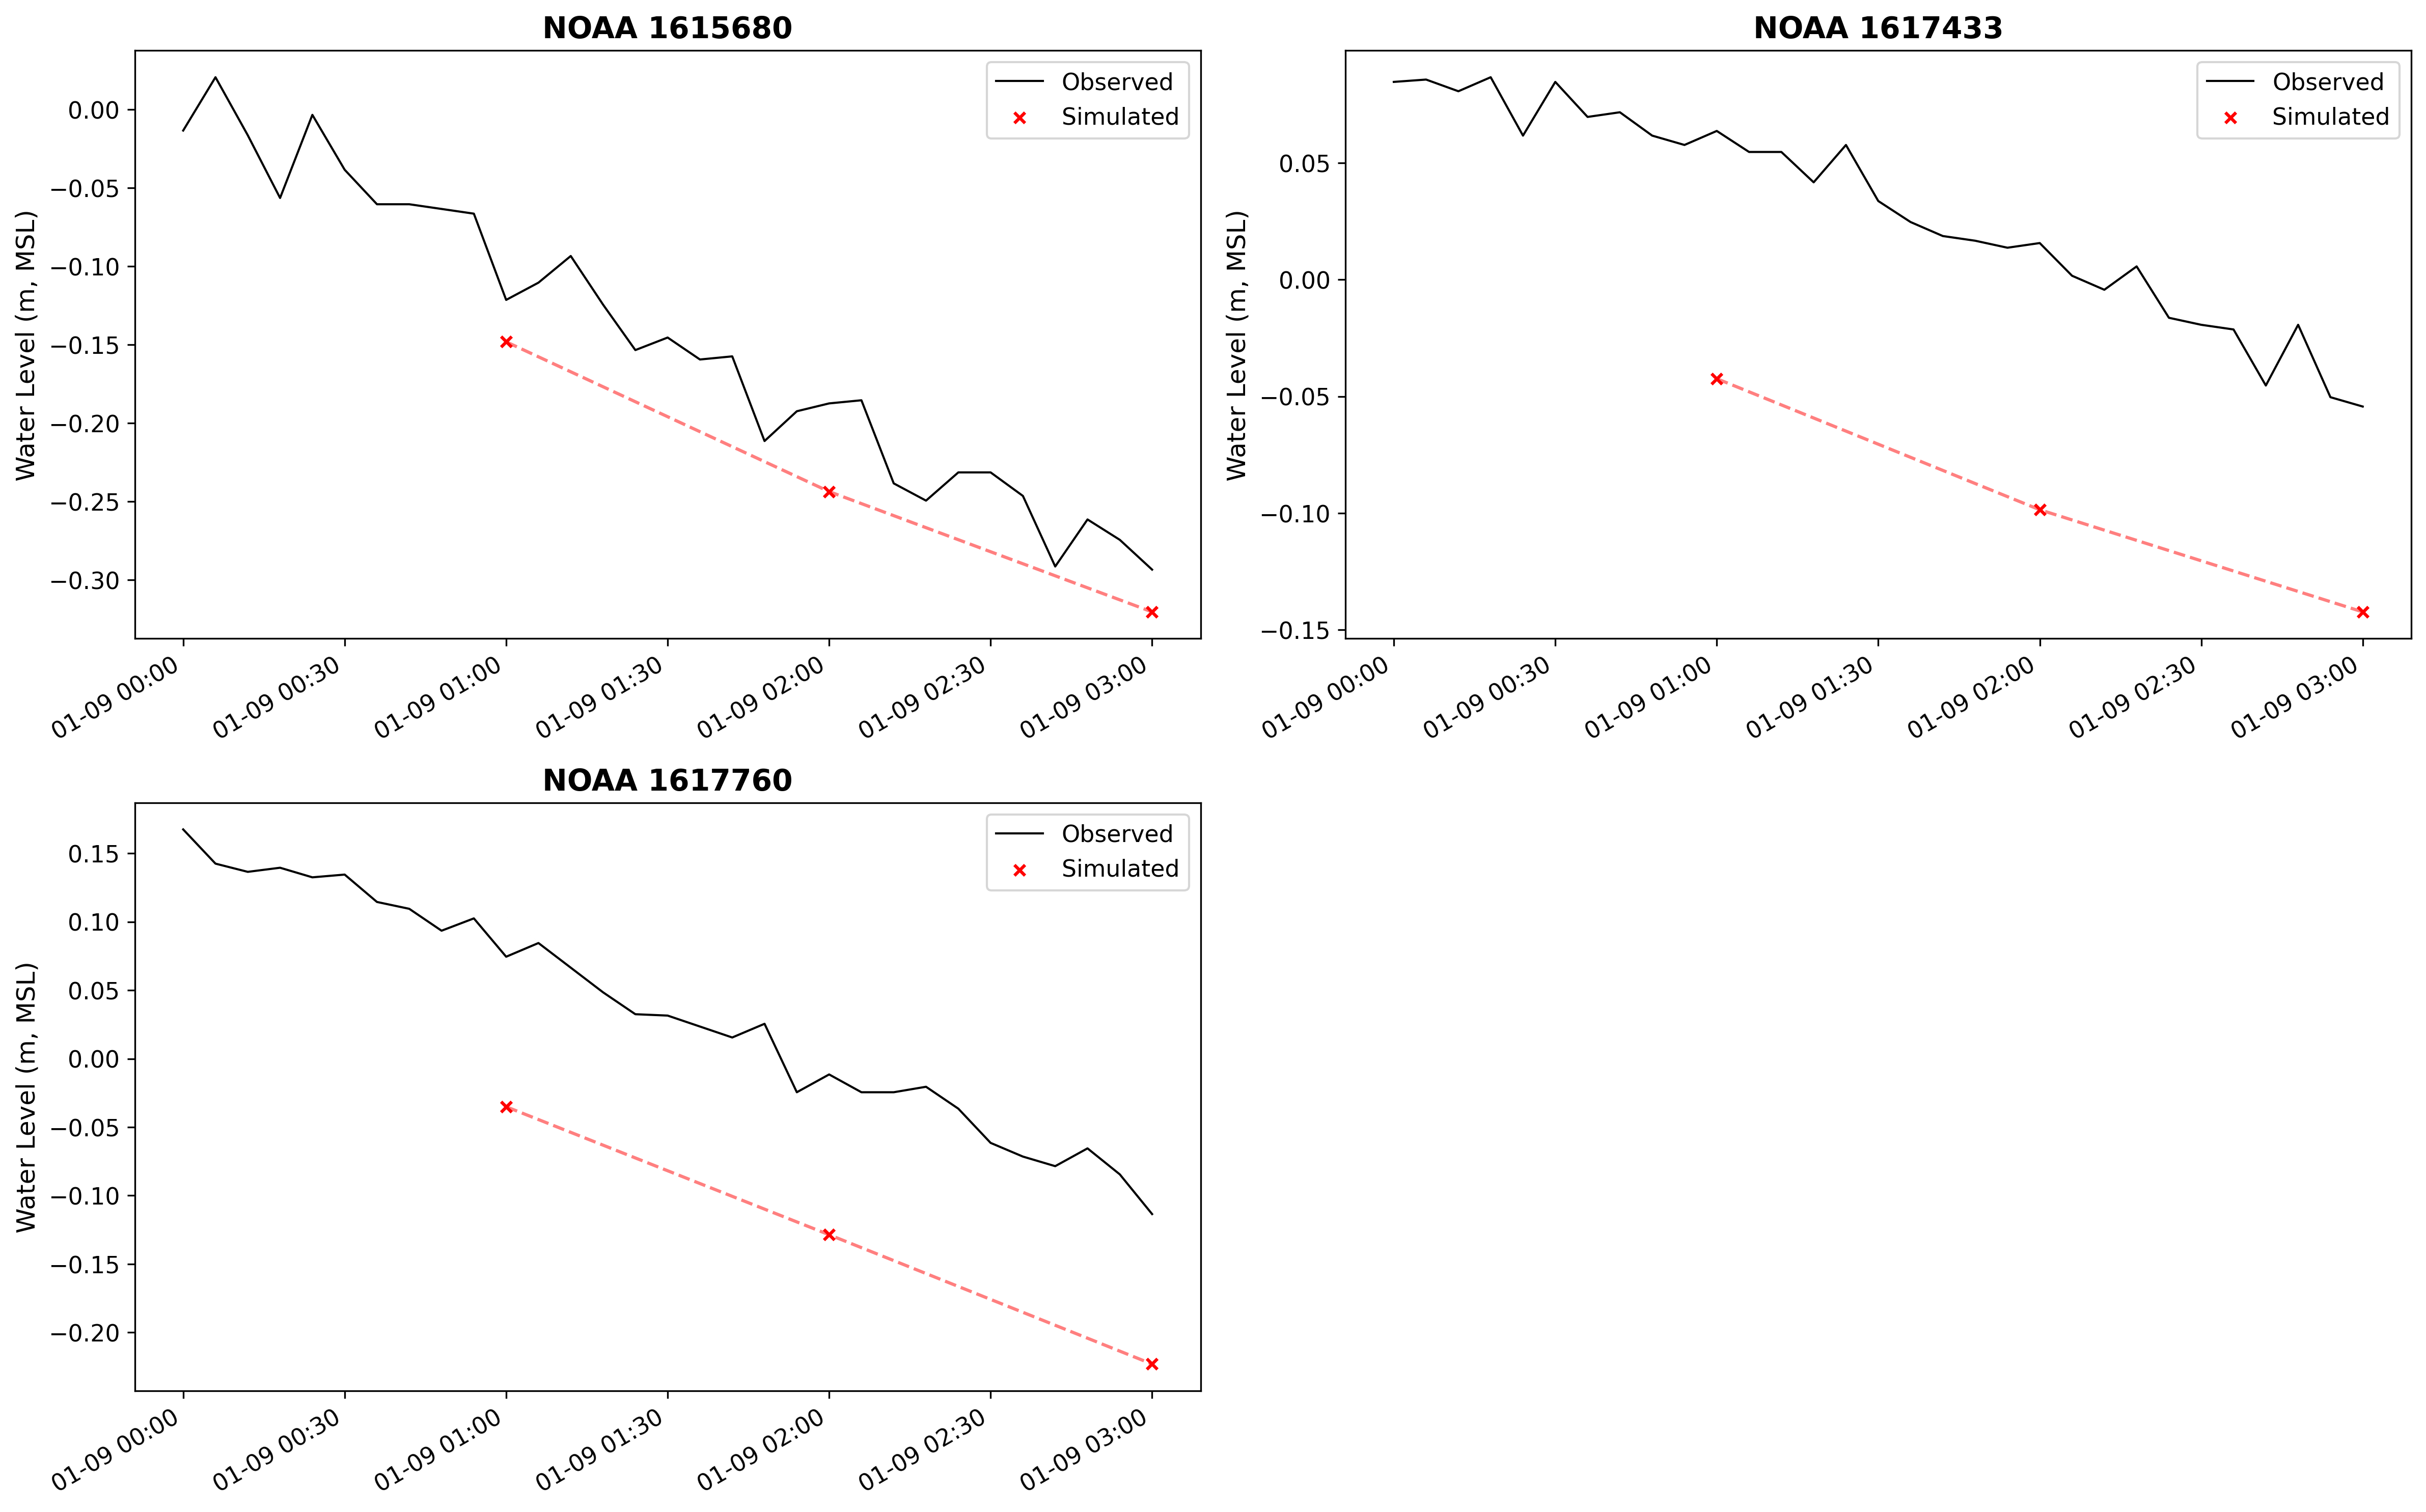

In [4]:
from IPython.display import Image, display

figs_dir = Path("run/figs")
for png in sorted(figs_dir.glob("stations_comparison_*.png")):
    display(Image(filename=str(png), width=800))

## 4. Inspect outputs

In [5]:
outputs_dir = Path("run/outputs")
if outputs_dir.exists():
    all_outputs = sorted(outputs_dir.iterdir())
    for f in all_outputs[:20]:
        sz = f.stat().st_size
        label = f"{sz / 1e6:.1f} MB" if sz > 1e6 else f"{sz / 1e3:.1f} KB"
        print(f"  {f.name:<40s} {label}")
    if len(all_outputs) > 20:
        print(f"  ... and {len(all_outputs) - 20} more files")
else:
    print("No outputs directory found")

  JCG.out                                  95.3 KB
  coriolis.out                             117.3 MB
  fatal.error                              0.0 KB
  flux.out                                 0.0 KB
  global_to_local.prop                     27.3 MB
  local_to_global_000000                   189.7 MB
  local_to_global_000001                   190.5 MB
  maxdahv_000000                           60.3 MB
  maxdahv_000001                           61.0 MB
  maxelev_000000                           41.9 MB
  maxelev_000001                           42.4 MB
  mirror.out                               27.5 KB
  mirror.out.scribe                        1.2 KB
  nonfatal_000000                          7.2 KB
  nonfatal_000001                          0.1 KB
  out2d_1.nc                               141.2 MB
  out2d_2.nc                               141.2 MB
  out2d_3.nc                               141.2 MB
  param.out.nml                            7.1 KB
  staout_1                     

## Summary

This notebook ran the full SCHISM pipeline for Hawaii using the same
`CoastalCalibConfig` + `CoastalCalibRunner` API as SFINCS:

1. Pointed `prebuilt_dir` at the pre-built model files and
   `geogrid_file` at the WRF geogrid for regridding
2. Downloaded NWM and STOFS coastal data
3. Regridded atmospheric forcing onto the SCHISM mesh
4. Generated boundary conditions (elev2D.th.nc)
5. Prepared discharge inputs and partitioned the mesh
6. Ran `pschism` via `mpiexec`
7. Post-processed outputs and generated comparison plots

The interface is identical to the SFINCS workflow — only the
`model_config` fields differ (MPI layout vs. OpenMP threads).